In [1]:
from bs4 import BeautifulSoup
import requests 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

Names = []
Rating = []
Reviews = []
Cities = []
Occasions = []
Posted_On = []

In [2]:
url = "https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page="
#url = "https://www.floweraura.com/reviews/p/10172/divine-butterscotch-cake?page="

for i in range(1,51):
    cnp = url+str(i)
    url_new = cnp
    r = requests.get(url_new)
    
    soup = BeautifulSoup(r.text, "html.parser")
    
    main = soup.find("div", {"class":"review-left-container"})
    
    sub = main.find_all("div", {"class":"new-review-card-container"})
    
    for i in sub:
        name = i.find("span", {"class":"review-author-name"})
        Names.append(name.text.title())
    
        city = i.find_all("span", {"class":"review-meta-details"})
        Cities.append(city[0].text.title())
        try:
            Occasions.append(city[1].text.title())
        except:
            Occasions.append(np.nan)
            
        date = i.find_all("span")
        try:
            Posted_On.append(date[4].text)
        except:
            Posted_On.append(np.nan)
    
        rating = i.find("span", {"class":"star-count-container"})
        Rating.append(rating.text)
    
        review = i.find_all("div")
        Reviews.append(review[-1].text)

    
    

In [3]:
df = pd.DataFrame({'Names':Names, "Citites":Cities, "Posted_On":Posted_On, "Occasion":Occasions, "Ratings":Rating, "Reviews":Reviews})
df.to_csv("Flower_aura_product_reviews.csv")

In [4]:
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shreya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shreya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Shreya\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
df = pd.read_csv("Flower_aura_product_reviews.csv") 
df.head()

,Unnamed: 0,Names,Citites,Posted_On,Occasion,Ratings,Reviews
0,0,Ramesh Kumar Pariyar,Bengaluru,Posted On : 7th Jan 2026,Occassion : Birthday,5,Great experience with FlowerAura.Delivery was ...
1,1,Anki M,Shillong,Posted On : 21st Oct 2025,NaN,5,Fresh flowers...liked it.
2,2,Suraj Chaunal,Noida,Posted On : 23rd Sep 2025,Occassion : Birthday,5,the flowers were fresh and colorful. TBH they ...
3,3,Bakiyalakshmi,Bangalore,Posted On : 22nd Sep 2025,Occassion : Anniversary,5,"Very fresh flowers, delivered on time with bea..."
4,4,Pulak.Pal77,Kolkata,Posted On : 19th Sep 2025,Occassion : Birthday,5,Roses quality is very nice.


## Remove Duplicates

In [9]:
df.drop(columns=['Unnamed: 0'], inplace=True)

df.drop_duplicates(subset='Reviews', inplace=True)

df.shape

(408, 6)

# Handle Missing Values

In [10]:
df[['Reviews', 'Ratings']].isnull().sum()

Reviews    1
Ratings    0
dtype: int64

In [12]:
df = df.dropna(subset=['Reviews', 'Ratings']).copy()

df.loc[:, 'Reviews'] = df['Reviews'].astype(str)

df.shape

(407, 6)

# Convert Reviews to Lowercase

In [13]:
df['cleaned_review'] = df['Reviews'].str.lower()

df[['Reviews', 'cleaned_review']].head()

,Reviews,cleaned_review
0,Great experience with FlowerAura.Delivery was ...,great experience with floweraura.delivery was ...
1,Fresh flowers...liked it.,fresh flowers...liked it.
2,the flowers were fresh and colorful. TBH they ...,the flowers were fresh and colorful. tbh they ...
3,"Very fresh flowers, delivered on time with bea...","very fresh flowers, delivered on time with bea..."
4,Roses quality is very nice.,roses quality is very nice.


In [15]:
df['cleaned_review'] = df['cleaned_review'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)

df['cleaned_review'] = df['cleaned_review'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

df[['Reviews', 'cleaned_review']].head()

,Reviews,cleaned_review
0,Great experience with FlowerAura.Delivery was ...,great experience with flowerauradelivery was o...
1,Fresh flowers...liked it.,fresh flowersliked it
2,the flowers were fresh and colorful. TBH they ...,the flowers were fresh and colorful tbh they w...
3,"Very fresh flowers, delivered on time with bea...",very fresh flowers delivered on time with beau...
4,Roses quality is very nice.,roses quality is very nice


In [16]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = word_tokenize(text)                    
    tokens = [word for word in tokens if word not in stop_words]   
    tokens = [lemmatizer.lemmatize(word) for word in tokens]       
    return " ".join(tokens)

In [17]:
df['cleaned_review'] = df['cleaned_review'].apply(preprocess_text)

df[['Reviews', 'cleaned_review']].head()

,Reviews,cleaned_review
0,Great experience with FlowerAura.Delivery was ...,great experience flowerauradelivery time produ...
1,Fresh flowers...liked it.,fresh flowersliked
2,the flowers were fresh and colorful. TBH they ...,flower fresh colorful tbh better expected thanks
3,"Very fresh flowers, delivered on time with bea...",fresh flower delivered time beautiful packagin...
4,Roses quality is very nice.,rose quality nice


# Sentiment Analysis Using TextBlob

In [18]:
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

df[['polarity', 'subjectivity']] = df['cleaned_review'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

df[['cleaned_review', 'polarity', 'subjectivity']].head()

,cleaned_review,polarity,subjectivity
0,great experience flowerauradelivery time produ...,0.452381,0.507143
1,fresh flowersliked,0.300000,0.500000
2,flower fresh colorful tbh better expected thanks,0.240000,0.400000
3,fresh flower delivered time beautiful packagin...,0.502381,0.690476
4,rose quality nice,0.600000,0.975000


# Classify Sentiment

In [19]:
def classify_sentiment(polarity):
    if polarity >= 0.1:
        return "Positive"
    else:
        return "Negative"

df['sentiment'] = df['polarity'].apply(classify_sentiment)

df[['polarity', 'sentiment']].head()

,polarity,sentiment
0,0.452381,Positive
1,0.300000,Positive
2,0.240000,Positive
3,0.502381,Positive
4,0.600000,Positive


# Sentiment Distribution

In [20]:
df['sentiment'].value_counts()

sentiment
Positive    350
Negative     57
Name: count, dtype: int64

In [21]:
df['sentiment'].value_counts(normalize=True) * 100

sentiment
Positive    85.995086
Negative    14.004914
Name: proportion, dtype: float64

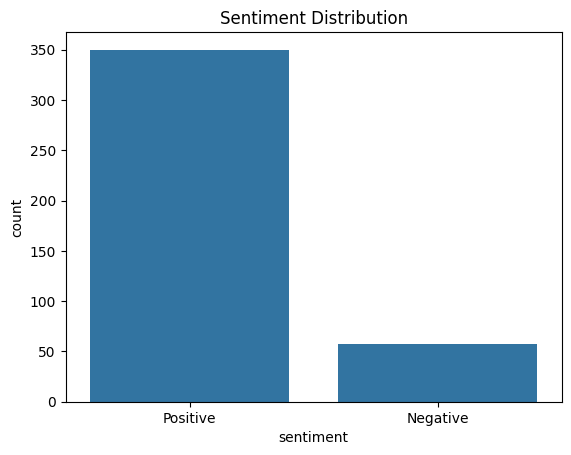

In [22]:
sns.countplot(data=df, x='sentiment')
plt.title("Sentiment Distribution")
plt.show()

# Check Rating vs Sentiment Correlation

In [23]:
df.groupby('sentiment')['Ratings'].mean()

sentiment
Negative    4.859649
Positive    4.914286
Name: Ratings, dtype: float64

In [24]:
df[['Ratings', 'polarity']].corr()

,Ratings,polarity
Ratings,1.000000,0.021596
polarity,0.021596,1.000000


## Insight 
There is almost no linear relationship between numeric ratings and text polarity.

This suggests:

Customers may give high ratings even when mentioning minor complaints.

Text-based sentiment captures nuance that numeric ratings miss.

Relying only on star ratings may hide dissatisfaction signals.



# Review Length Analysis

In [25]:
df['review_length'] = df['cleaned_review'].apply(lambda x: len(x.split()))
df.groupby('sentiment')['review_length'].mean()

sentiment
Negative    3.491228
Positive    4.905714
Name: review_length, dtype: float64

# Analytical Insight

Reviews are concise in nature.

Sentiment polarity may be sensitive due to short review lengths.

Numeric ratings remain consistently high despite slight textual negativity.

The dataset suggests strong overall satisfaction with minor verbal complaints.

# Word Cloud

In [26]:
!pip install wordcloud
from wordcloud import WordCloud

Defaulting to user installation because normal site-packages is not writeable


In [27]:
positive_text = " ".join(df[df['sentiment']=="Positive"]['cleaned_review'])
negative_text = " ".join(df[df['sentiment']=="Negative"]['cleaned_review'])

# Positive Review Word Cloud

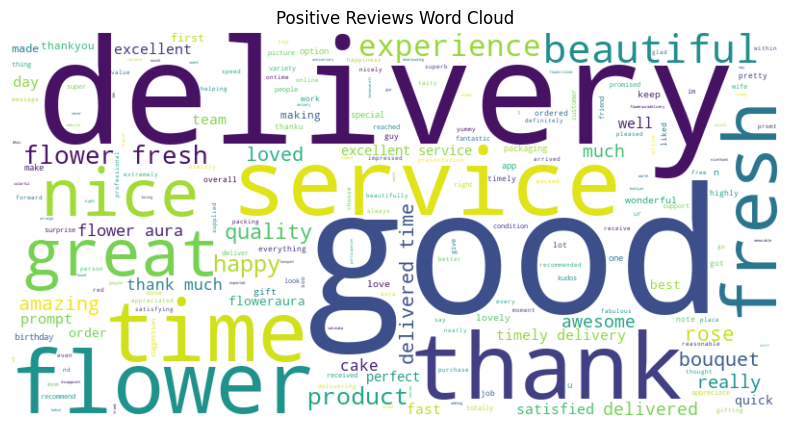

In [28]:
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Reviews Word Cloud")
plt.show()

# Negative Review Word Cloud

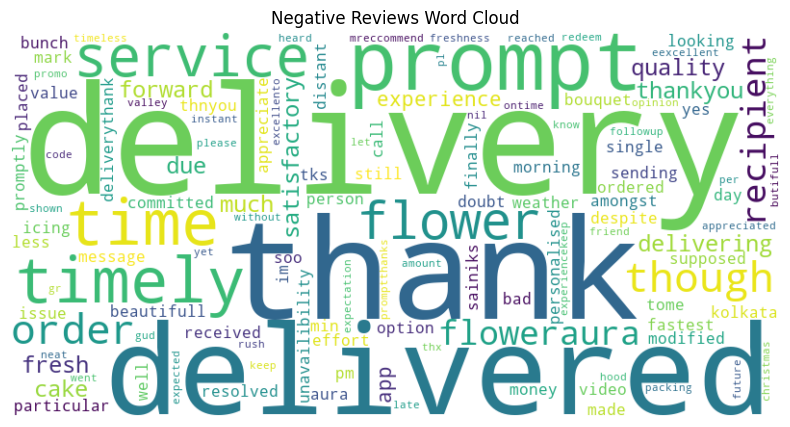

In [29]:
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Reviews Word Cloud")
plt.show()

# Real Insight
Delivery is the central theme in both positive and negative reviews.

Time / promptness is the biggest driver of sentiment.

Product quality appears less controversial than logistics.

Negative reviews are not aggressive, mostly mild complaints.

This suggests:

Core issue area = delivery timing

Product satisfaction seems strong

Operational efficiency matters most